In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import torchvision.transforms as transforms

print("Libraries Loaded!")

Libraries Loaded!


In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

mps


In [4]:
PROJECT_ROOT = Path("..")

DATASET_PATH = PROJECT_ROOT / "datasets" / "COVID-19_Radiography_Dataset"

CLASSES = [
    "COVID",
    "Normal",
    "Lung_Opacity",
    "Viral Pneumonia"
]

In [5]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [6]:
image_paths = []
labels = []

for label, cls in enumerate(CLASSES):

    folder = DATASET_PATH / cls / "images"

    for img in folder.glob("*.png"):

        image_paths.append(img)

        labels.append(label)

df = pd.DataFrame({

    "image": image_paths,

    "label": labels

})

df.head()

,image,label
0,../datasets/COVID-19_Radiography_Dataset/COVID...,0
1,../datasets/COVID-19_Radiography_Dataset/COVID...,0
2,../datasets/COVID-19_Radiography_Dataset/COVID...,0
3,../datasets/COVID-19_Radiography_Dataset/COVID...,0
4,../datasets/COVID-19_Radiography_Dataset/COVID...,0


In [7]:
print("Total Images :", len(df))

Total Images : 21165


In [8]:
train_df, temp_df = train_test_split(

    df,

    test_size=0.30,

    random_state=42,

    stratify=df["label"]

)

val_df, test_df = train_test_split(

    temp_df,

    test_size=0.50,

    random_state=42,

    stratify=temp_df["label"]

)

print(len(train_df))
print(len(val_df))
print(len(test_df))

14815
3175
3175


In [9]:
print("Train")

print(train_df["label"].value_counts())

print()

print("Validation")

print(val_df["label"].value_counts())

print()

print("Test")

print(test_df["label"].value_counts())

Train
label
1    7134
2    4208
0    2531
3     942
Name: count, dtype: int64

Validation
label
1    1529
2     902
0     543
3     201
Name: count, dtype: int64

Test
label
1    1529
2     902
0     542
3     202
Name: count, dtype: int64


In [10]:
class ChestXrayDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.loc[idx, "image"]

        label = self.df.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:

            image = self.transform(image)

        return image, label

In [11]:
train_dataset = ChestXrayDataset(

    train_df,

    train_transform

)

val_dataset = ChestXrayDataset(

    val_df,

    test_transform

)

test_dataset = ChestXrayDataset(

    test_df,

    test_transform

)

In [12]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True,

    num_workers=0

)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=0

)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=0

)

In [13]:
images, labels = next(iter(train_loader))

print(images.shape)

print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


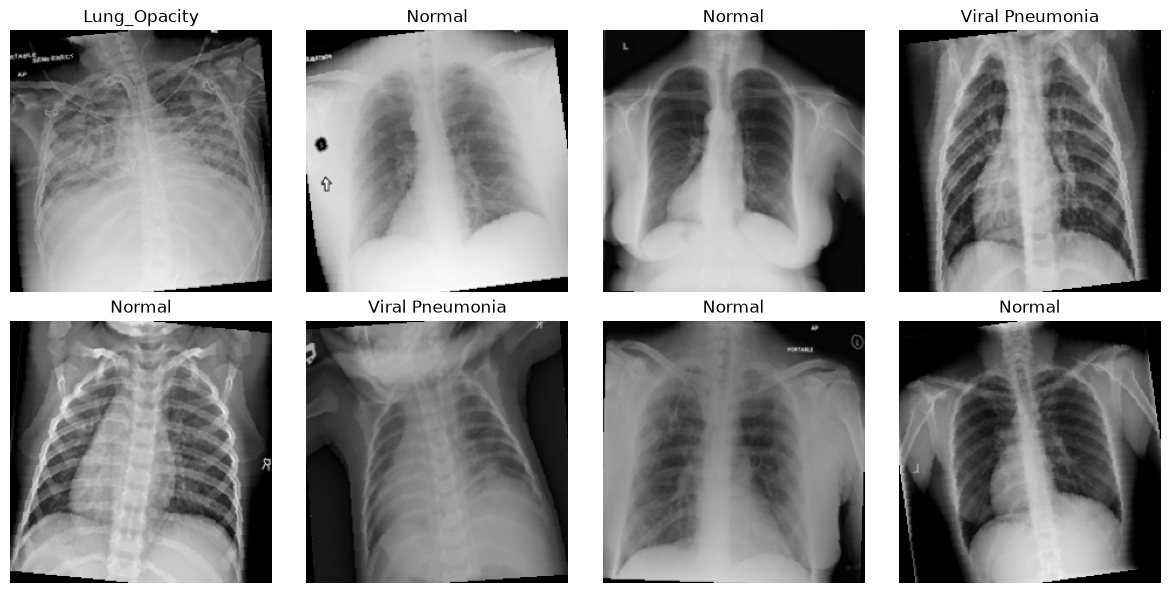

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    img = images[i].permute(1, 2, 0).numpy()

    img = img * np.array([0.229, 0.224, 0.225])
    img = img + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(CLASSES[labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()